## Install libraries

In [37]:
!pip install xgboost
!pip install lightgbm catboost

## Import libraries

In [38]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file Input/Output (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# for starting the environment, use as it is
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/manual-fire-dataset/fire_data.csv
/kaggle/input/smoke-detection-dataset/smoke_detection_iot.csv


## Import kaggle dataset

In [39]:
# for getting data from the input section of folder having excel file in it
kdata = pd.read_csv("/kaggle/input/smoke-detection-dataset/smoke_detection_iot.csv")
# gives first 5 rows of data
kdata.head(10)

,Unnamed: 0,UTC,Temperature[C],Humidity[%],TVOC[ppb],eCO2[ppm],Raw H2,Raw Ethanol,Pressure[hPa],PM1.0,PM2.5,NC0.5,NC1.0,NC2.5,CNT,Fire Alarm
0,0,1654733331,20.000,57.36,0,400,12306,18520,939.735,0.0,0.00,0.0,0.000,0.00,0,0
1,1,1654733332,20.015,56.67,0,400,12345,18651,939.744,0.0,0.00,0.0,0.000,0.00,1,0
2,2,1654733333,20.029,55.96,0,400,12374,18764,939.738,0.0,0.00,0.0,0.000,0.00,2,0
3,3,1654733334,20.044,55.28,0,400,12390,18849,939.736,0.0,0.00,0.0,0.000,0.00,3,0
4,4,1654733335,20.059,54.69,0,400,12403,18921,939.744,0.0,0.00,0.0,0.000,0.00,4,0
5,5,1654733336,20.073,54.12,0,400,12419,18998,939.725,0.0,0.00,0.0,0.000,0.00,5,0
6,6,1654733337,20.088,53.61,0,400,12432,19058,939.738,0.0,0.00,0.0,0.000,0.00,6,0
7,7,1654733338,20.103,53.20,0,400,12439,19114,939.758,0.0,0.00,0.0,0.000,0.00,7,0
8,8,1654733339,20.117,52.81,0,400,12448,19155,939.758,0.0,0.00,0.0,0.000,0.00,8,0
9,9,1654733340,20.132,52.46,0,400,12453,19195,939.756,0.9,3.78,0.0,4.369,2.78,9,0


## Intial Correlation Analysis

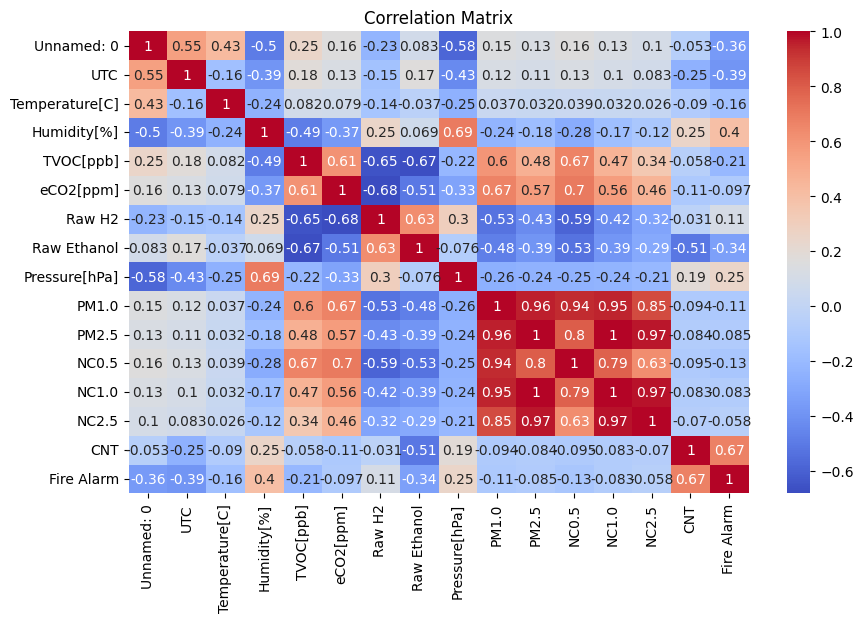

In [40]:
corr = kdata.corr()

# Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

## Import Custom Dataset

In [41]:
# for getting data from the input section of folder having excel file in it
data = pd.read_csv("/kaggle/input/manual-fire-dataset/fire_data.csv")
# gives first 5 rows of data
data.head(10)

,eco2,humidity,pressure,raw_ethanol,raw_h2,temperature,timestamp,fire_alarm
0,400,70.11423,1006.06000,3166,499,32.72419,9,0
1,409,70.06827,1006.04999,3181,431,32.69844,11,0
2,400,70.03365,1006.01001,3197,436,32.72800,12,0
3,400,70.01781,1006.03998,3200,435,32.76405,13,0
4,400,69.98224,1006.09003,3212,429,32.77359,14,0
5,504,69.94447,1006.04999,3214,408,32.78961,15,0
6,608,70.00075,1005.96002,3218,400,32.81021,16,0
7,473,70.04767,1006.01001,3218,389,32.82604,17,0
8,473,70.21056,1006.02002,3224,371,32.84340,18,0
9,400,70.32271,1006.06000,3228,367,32.85694,19,0


## Basic Info and Summary

In [42]:
# gives info of column data types
# Shape of the dataset
print("Shape:", data.shape)

# Column names and types
print(data.info())

# Statistical summary
print(data.describe())

print("Total number of Null values in each column:")
print(data.isnull().sum())

Shape: (6121, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6121 entries, 0 to 6120
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   eco2         6121 non-null   int64  
 1   humidity     6121 non-null   float64
 2   pressure     6121 non-null   float64
 3   raw_ethanol  6121 non-null   int64  
 4   raw_h2       6121 non-null   int64  
 5   temperature  6121 non-null   float64
 6   timestamp    6121 non-null   int64  
 7   fire_alarm   6121 non-null   int64  
dtypes: float64(3), int64(5)
memory usage: 382.7 KB
None
               eco2     humidity     pressure  raw_ethanol       raw_h2  \
count   6121.000000  6121.000000  6121.000000  6121.000000  6121.000000   
mean    1295.999510    53.587865  1006.083358  2994.812286   116.727986   
std     2748.151382    15.887435     0.217600   273.917184   102.059461   
min      400.000000    23.125170  1005.500000  1606.000000    25.000000   
25%      488.000000    39

## Remove Useless columns

In [43]:
X = data.drop('timestamp',axis =1) # delete time column, not needed

## Intial Correlation Analysis

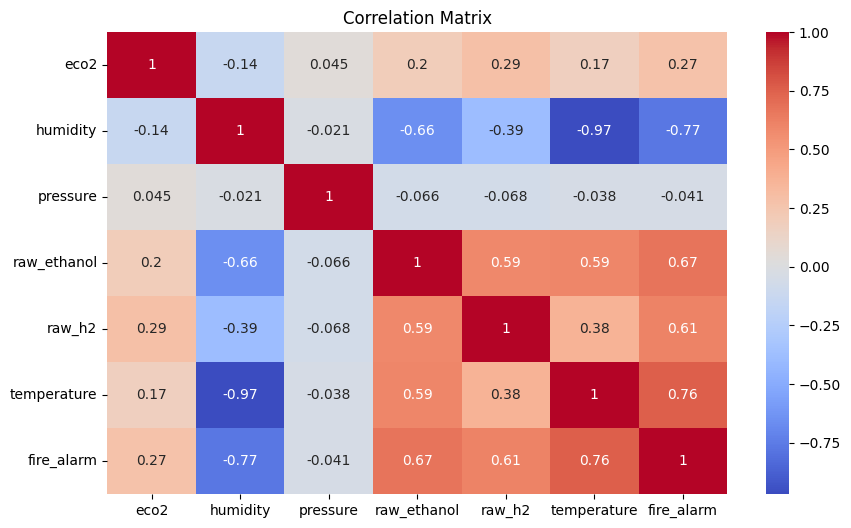

In [44]:
# Correlation matrix
corr = X.corr()

# Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

## Target Variable Analysis

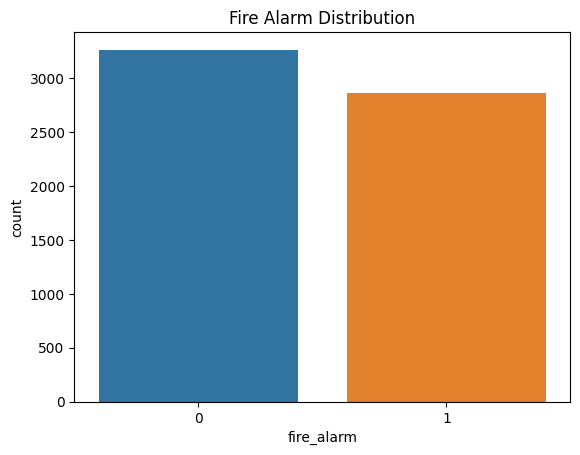

In [45]:
# Count of each class in Fire Alarm
sns.countplot(x='fire_alarm', data=X)
plt.title("Fire Alarm Distribution")
plt.show()

## Balance Dataset

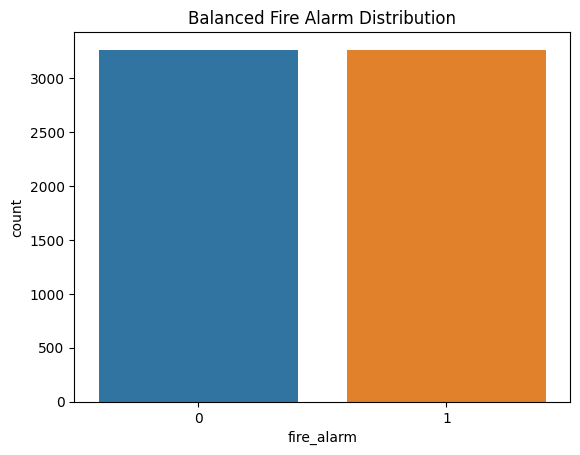

✅ Rows before balancing: 6121
✅ Rows after balancing: 6526
fire_alarm
1    3263
0    3263
Name: count, dtype: int64


In [46]:
from sklearn.utils import resample
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd



# Separate majority and minority classes
majority = X[X['fire_alarm'] == 0]  # more 0s → majority
minority = X[X['fire_alarm'] == 1]  # fewer 1s → minority

# --- Upsample the minority class ---
minority_upsampled = resample(
    minority,
    replace=True,                    # sample with replacement
    n_samples=len(majority),         # match majority count
    random_state=42
)

# --- Combine back to get balanced data ---
X_balanced = pd.concat([majority, minority_upsampled])

# --- Shuffle the data to mix both classes ---
X_balanced = X_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# --- Plot class balance ---
sns.countplot(x='fire_alarm', data=X_balanced)
plt.title("Balanced Fire Alarm Distribution")
plt.show()

print("✅ Rows before balancing:", X.shape[0])
print("✅ Rows after balancing:", X_balanced.shape[0])
print(X_balanced['fire_alarm'].value_counts())


## Correlation Analysis

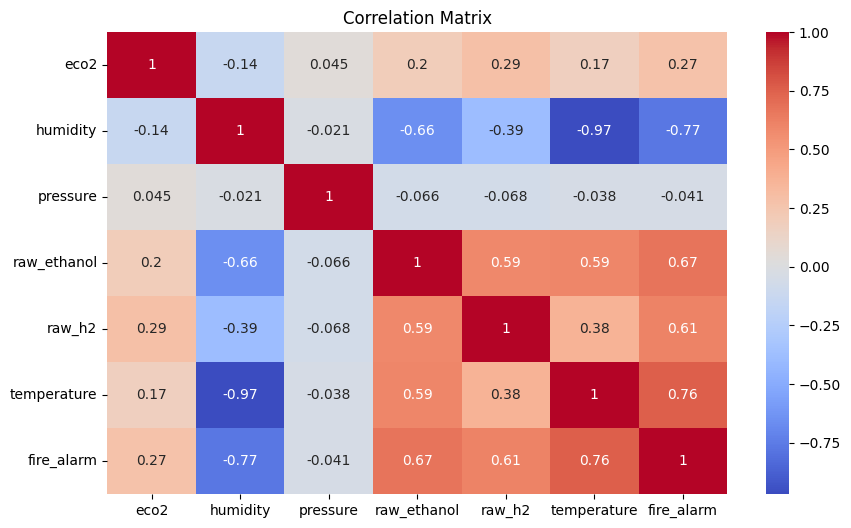

In [47]:
# Correlation matrix
corr = X.corr()

# Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

## Feature Distributions

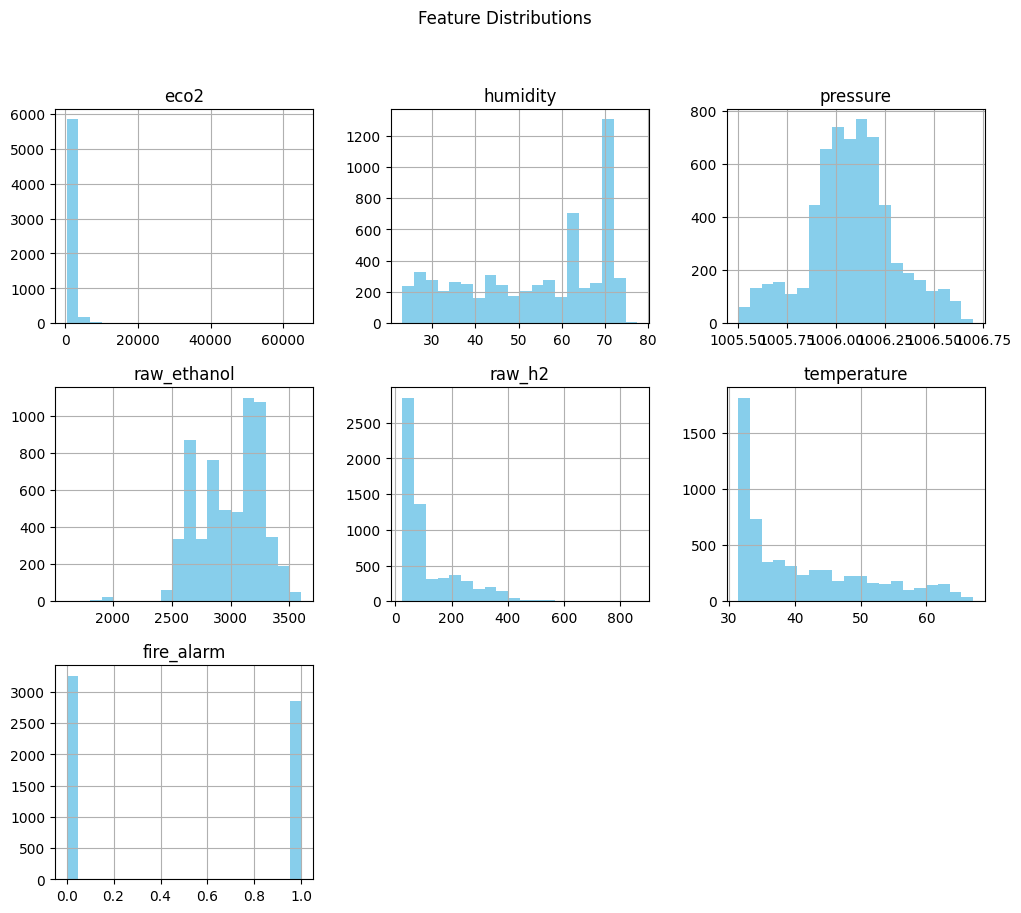

In [48]:
# Histograms for numerical features
X.hist(bins=20, figsize=(12,10), color='skyblue')
plt.suptitle("Feature Distributions")
plt.show()

## Boxplots for Outlier Detection

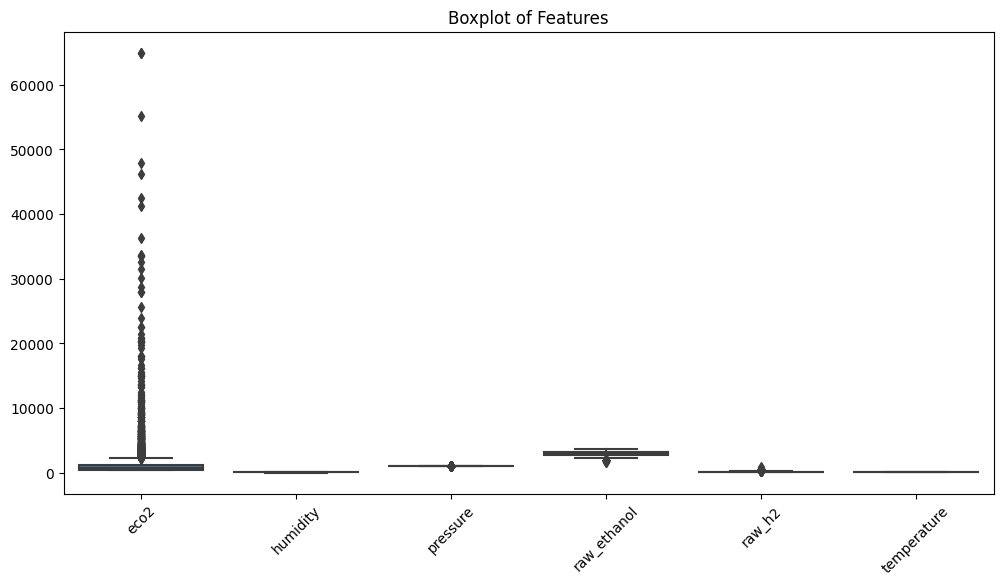

In [49]:
plt.figure(figsize=(12,6))
sns.boxplot(data=X.drop(columns='fire_alarm'))
plt.title("Boxplot of Features")
plt.xticks(rotation=45)
plt.show()

## Pairplots for Relationships 

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated a

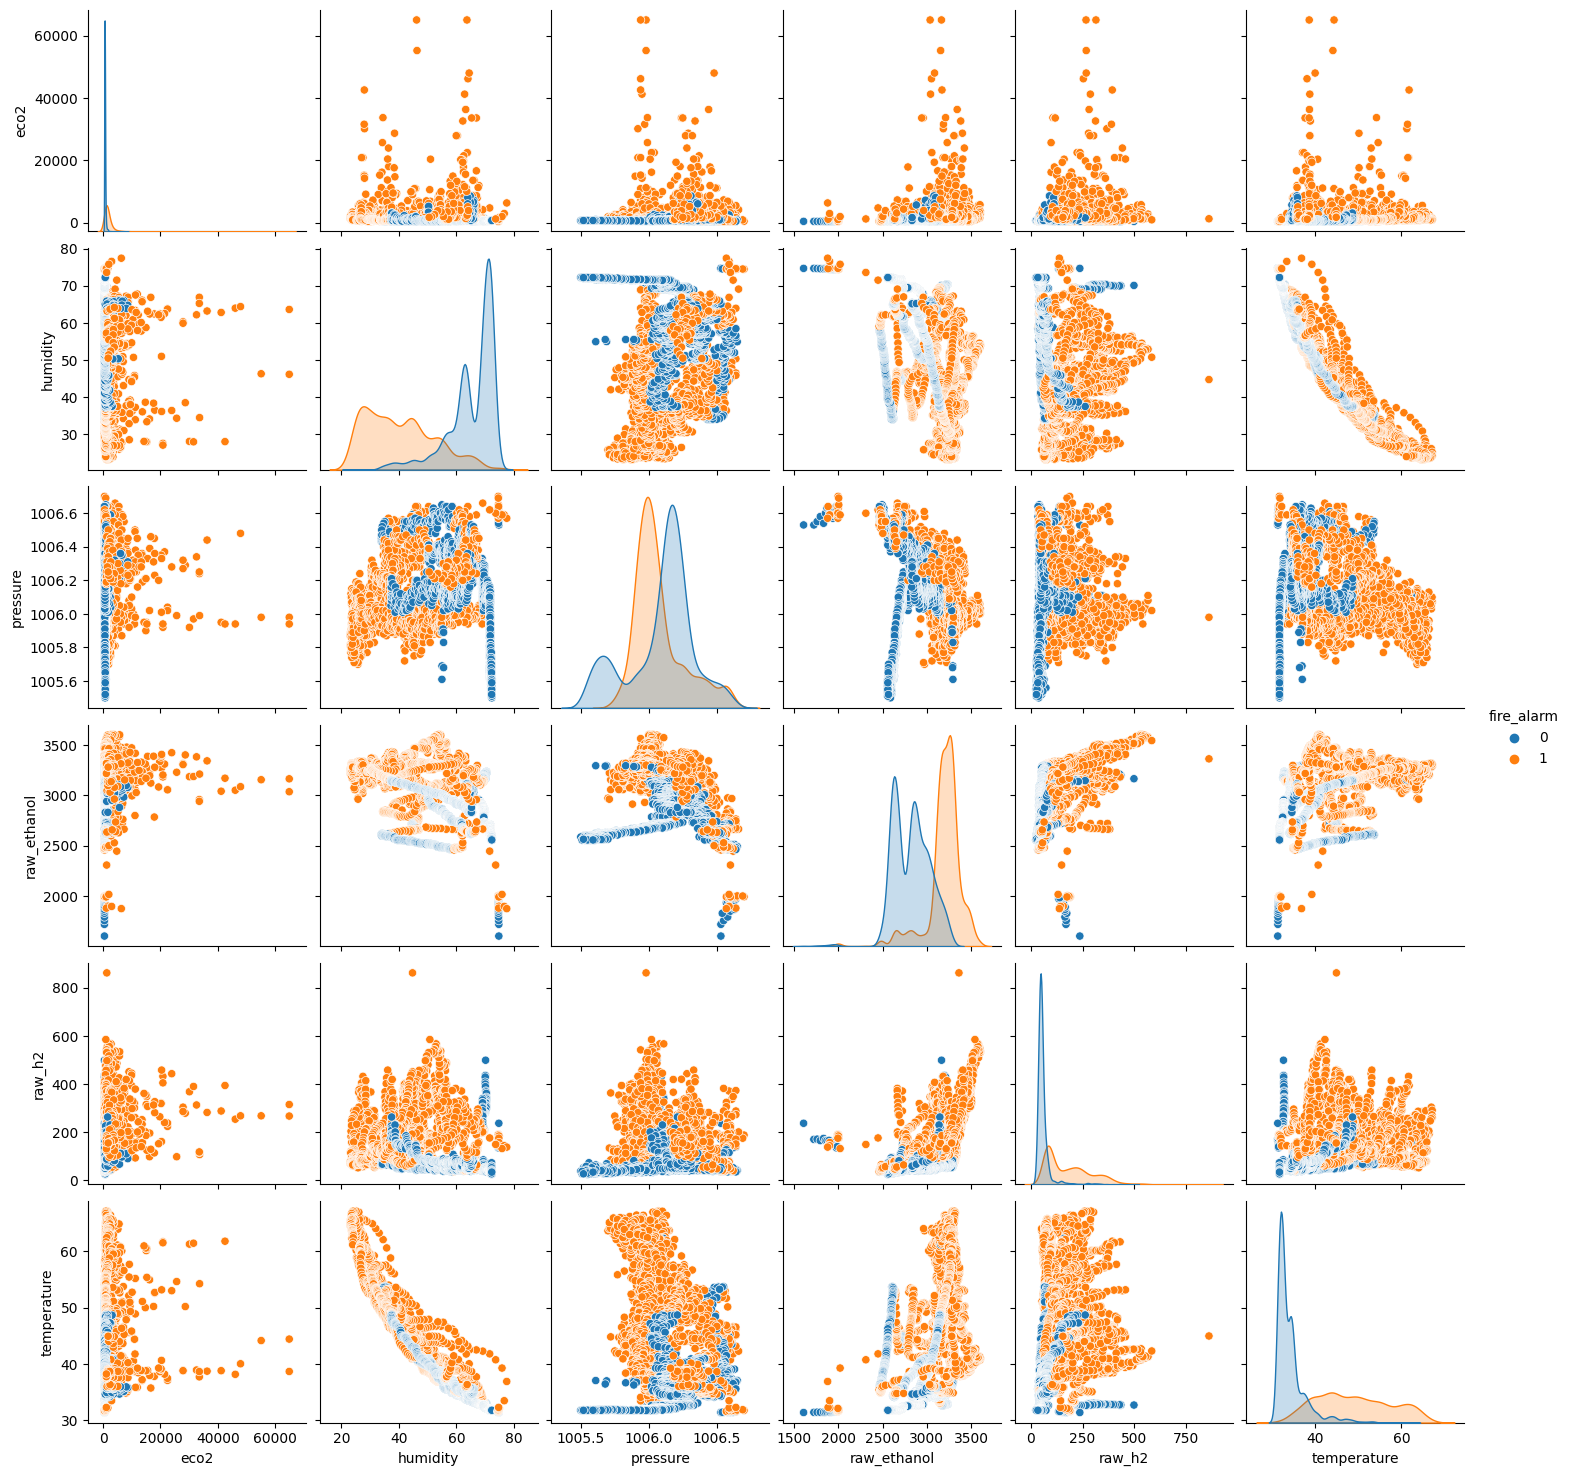

In [50]:
# Pairplot for small datasets
sns.pairplot(X, hue='fire_alarm')
plt.show()

## Feature vs Target Analysis

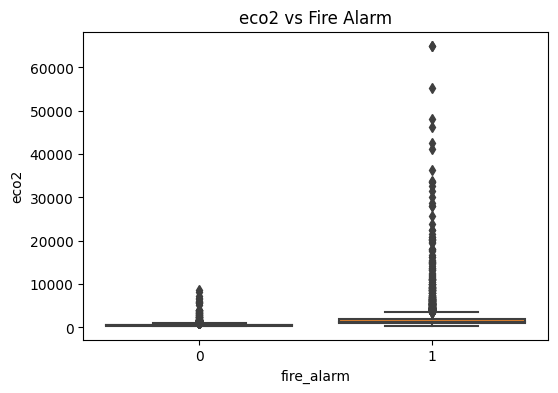

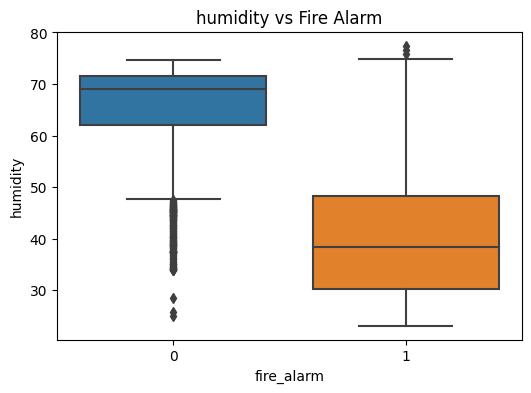

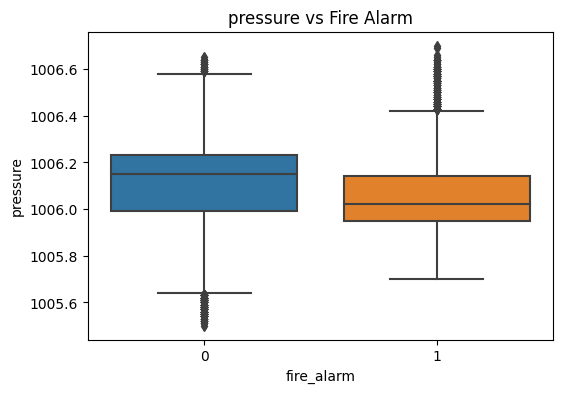

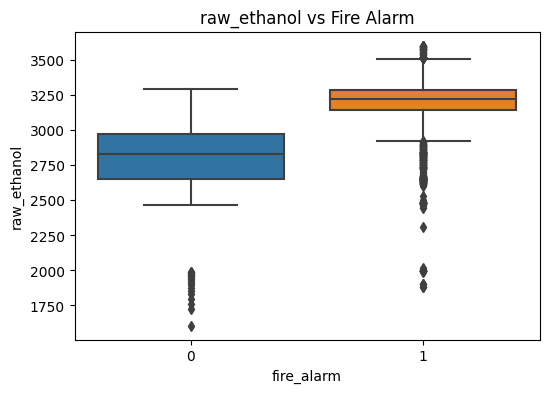

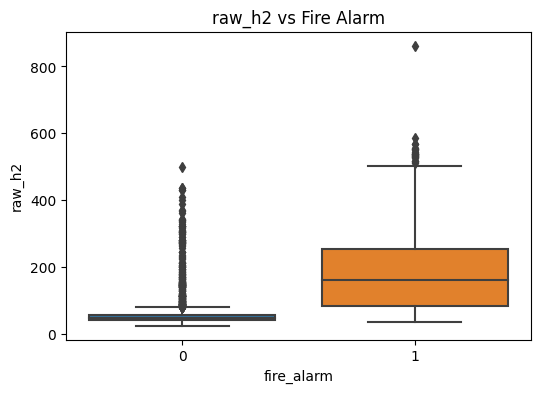

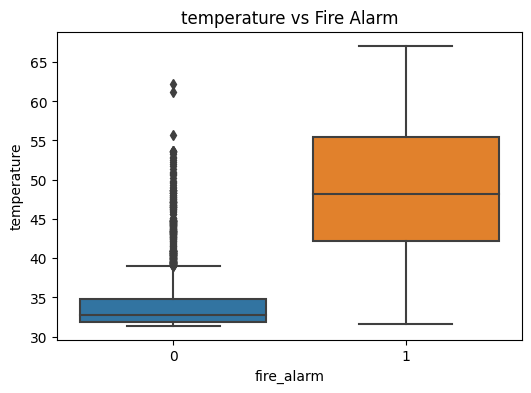

In [51]:
for col in X.columns[:-1]:  # excluding target
    plt.figure(figsize=(6,4))
    sns.boxplot(x='fire_alarm', y=col, data=X)
    plt.title(f'{col} vs Fire Alarm')
    plt.show()
    

## Create Dependent Variable

In [52]:
y = X['fire_alarm'] # Fire Alarm column only as output

y.head()

0    0
1    0
2    0
3    0
4    0
Name: fire_alarm, dtype: int64

## Create independant Variable

In [53]:
pd.set_option('display.max_rows', None)

X = X.drop('fire_alarm',axis =1)

X.head(10)

,eco2,humidity,pressure,raw_ethanol,raw_h2,temperature
0,400,70.11423,1006.06000,3166,499,32.72419
1,409,70.06827,1006.04999,3181,431,32.69844
2,400,70.03365,1006.01001,3197,436,32.72800
3,400,70.01781,1006.03998,3200,435,32.76405
4,400,69.98224,1006.09003,3212,429,32.77359
5,504,69.94447,1006.04999,3214,408,32.78961
6,608,70.00075,1005.96002,3218,400,32.81021
7,473,70.04767,1006.01001,3218,389,32.82604
8,473,70.21056,1006.02002,3224,371,32.84340
9,400,70.32271,1006.06000,3228,367,32.85694


## Dividing dataset into test and train data

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib  # for saving models
import os

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neural_network import MLPClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, log_loss

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

accuracies = {}
losses = {}
filesizes = {}


X_train.columns = [str(col).replace('[','_').replace(']','_').replace('{','_').replace('}','_')
                              .replace('<','_').replace('>','_').replace('"','_').replace('\\','_')
                   for col in X_train.columns]
X_test.columns = [str(col).replace('[','_').replace(']','_').replace('{','_').replace('}','_')
                             .replace('<','_').replace('>','_').replace('"','_').replace('\\','_')
                  for col in X_test.columns]


# Tryiing Different models...

# Tryiing Different models...

## KNeighborsClassifier

In [55]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
acc_knn = accuracy_score(y_test, y_pred_knn)
loss_knn = log_loss(y_test, knn.predict_proba(X_test))
print("KNN Accuracy:", acc_knn * 100, "%")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
joblib.dump(knn, "/kaggle/working/knn_model.pkl")

# Calculate size
file_path = "/kaggle/working/knn_model.pkl"
file_size = os.path.getsize(file_path)  # in bytes

# Convert to MB for better readability
file_size_mb = file_size / (1024 * 1024)

print(f"Model size: {file_size_mb:.4f} MB")

accuracies["KNN"] = acc_knn
losses["KNN"] = loss_knn
filesizes["KNN"] = file_size_mb

KNN Accuracy: 96.97959183673468 %
Confusion Matrix:
 [[624  20]
 [ 17 564]]
Model size: 0.5558 MB


## LogisticRegression

In [56]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)
loss_lr = log_loss(y_test, lr.predict_proba(X_test))
print("Logistic Regression Accuracy:", acc_lr * 100, "%")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
joblib.dump(lr, "/kaggle/working/logistic_regression_model.pkl")

# Calculate size
file_path = "/kaggle/working/logistic_regression_model.pkl"
file_size = os.path.getsize(file_path)  # in bytes

# Convert to MB for better readability
file_size_mb = file_size / (1024 * 1024)

print(f"Model size: {file_size_mb:.4f} MB")


accuracies["Logistic Regression"] = acc_lr
losses["Logistic Regression"] = loss_lr
filesizes["Logistic Regression"] = file_size_mb

Logistic Regression Accuracy: 95.51020408163265 %
Confusion Matrix:
 [[620  24]
 [ 31 550]]
Model size: 0.0012 MB


## DecisionTreeClassifier

In [57]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)
loss_dt = log_loss(y_test, dt.predict_proba(X_test))
print("Decision Tree Accuracy:", acc_dt * 100, "%")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
joblib.dump(dt, "/kaggle/working/decision_tree_model.pkl")

# Calculate size
file_path = "/kaggle/working/decision_tree_model.pkl"
file_size = os.path.getsize(file_path)  # in bytes

# Convert to MB for better readability
file_size_mb = file_size / (1024 * 1024)

print(f"Model size: {file_size_mb:.4f} MB")

accuracies["Decision Tree"] = acc_dt
losses["Decision Tree"] = loss_dt
filesizes["Decision Tree"] = file_size_mb

Decision Tree Accuracy: 99.10204081632654 %
Confusion Matrix:
 [[636   8]
 [  3 578]]
Model size: 0.0099 MB


## RandomForestClassifier

In [58]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
loss_rf = log_loss(y_test, rf.predict_proba(X_test))
print("Random Forest Accuracy:", acc_rf * 100, "%")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
joblib.dump(rf, "/kaggle/working/random_forest_model.pkl")

# Calculate size
file_path = "/kaggle/working/random_forest_model.pkl"
file_size = os.path.getsize(file_path)  # in bytes

# Convert to MB for better readability
file_size_mb = file_size / (1024 * 1024)

print(f"Model size: {file_size_mb:.4f} MB")

accuracies["Random Forest"] = acc_rf
losses["Random Forest"] = loss_rf
filesizes["Random Forest"] = file_size_mb

Random Forest Accuracy: 99.26530612244898 %
Confusion Matrix:
 [[636   8]
 [  1 580]]
Model size: 1.0795 MB


## Support Vector Classifier

In [59]:
svc = SVC(probability=True, kernel='rbf')  # probability=True is needed for log_loss
svc.fit(X_train, y_train)

# Make predictions
y_pred_svc = svc.predict(X_test)
acc_svc = accuracy_score(y_test, y_pred_svc)
loss_svc = log_loss(y_test, svc.predict_proba(X_test))
print("SVC Accuracy:", acc_svc * 100, "%")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svc))

# Save the model
joblib.dump(svc, "/kaggle/working/svc_model.pkl")

# Calculate model size
file_path = "/kaggle/working/svc_model.pkl"
file_size = os.path.getsize(file_path)  # in bytes
file_size_mb = file_size / (1024 * 1024)  # Convert to MB
print(f"Model size: {file_size_mb:.4f} MB")

# Store metrics
accuracies["SVC"] = acc_svc
losses["SVC"] = loss_svc
filesizes["SVC"] = file_size_mb

SVC Accuracy: 93.3061224489796 %
Confusion Matrix:
 [[609  35]
 [ 47 534]]
Model size: 0.0766 MB


## XGBClassifier

In [60]:
# Initialize and train XGBoost
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train.values, y_train)

y_pred_xgb = xgb_model.predict(X_test)
acc_xgb = accuracy_score(y_test, y_pred_xgb)
loss_xgb = log_loss(y_test, xgb_model.predict_proba(X_test))

print("XGBoost Accuracy:", acc_xgb * 100, "%")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))

# Save the model
joblib.dump(xgb_model, "/kaggle/working/xgb_model.pkl")

file_path = "/kaggle/working/xgb_model.pkl"
file_size = os.path.getsize(file_path)  # in bytes
file_size_mb = file_size / (1024 * 1024)  # Convert to MB
print(f"Model size: {file_size_mb:.4f} MB")

# Store metrics
accuracies["XGBoost"] = acc_xgb
losses["XGBoost"] = loss_xgb
filesizes["XGBoost"] = file_size_mb

XGBoost Accuracy: 99.26530612244898 %
Confusion Matrix:
 [[637   7]
 [  2 579]]
Model size: 0.1469 MB


## Gradient Boosting

In [61]:
# --- Gradient Boosting ---
gb_model = GradientBoostingClassifier()
gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)
acc_gb = accuracy_score(y_test, y_pred_gb)
loss_gb = log_loss(y_test, gb_model.predict_proba(X_test))

print("Gradient Boosting Accuracy:", acc_gb * 100, "%")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_gb))

joblib.dump(gb_model, "/kaggle/working/gb_model.pkl")
file_path = "/kaggle/working/gb_model.pkl"
file_size_mb = os.path.getsize(file_path) / (1024 * 1024)
print(f"Model size: {file_size_mb:.4f} MB")

accuracies["GradientBoosting"] = acc_gb
losses["GradientBoosting"] = loss_gb
filesizes["GradientBoosting"] = file_size_mb

Gradient Boosting Accuracy: 99.0204081632653 %
Confusion Matrix:
 [[635   9]
 [  3 578]]
Model size: 0.1195 MB


## LightGBM

In [62]:
lgb_model = LGBMClassifier()
lgb_model.fit(X_train, y_train)

y_pred_lgb = lgb_model.predict(X_test)
acc_lgb = accuracy_score(y_test, y_pred_lgb)
loss_lgb = log_loss(y_test, lgb_model.predict_proba(X_test))

print("LightGBM Accuracy:", acc_lgb * 100, "%")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lgb))

joblib.dump(lgb_model, "/kaggle/working/lgb_model.pkl")
file_path = "/kaggle/working/lgb_model.pkl"
file_size_mb = os.path.getsize(file_path) / (1024 * 1024)
print(f"Model size: {file_size_mb:.4f} MB")

accuracies["LightGBM"] = acc_lgb
losses["LightGBM"] = loss_lgb
filesizes["LightGBM"] = file_size_mb

[LightGBM] [Info] Number of positive: 2277, number of negative: 2619
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000400 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1389
[LightGBM] [Info] Number of data points in the train set: 4896, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.465074 -> initscore=-0.139934
[LightGBM] [Info] Start training from score -0.139934
LightGBM Accuracy: 99.34693877551021 %
Confusion Matrix:
 [[637   7]
 [  1 580]]
Model size: 0.3284 MB


## CatBoost

In [63]:
cat_model = CatBoostClassifier(verbose=0)
cat_model.fit(X_train, y_train)

y_pred_cat = cat_model.predict(X_test)
acc_cat = accuracy_score(y_test, y_pred_cat)
loss_cat = log_loss(y_test, cat_model.predict_proba(X_test))

print("CatBoost Accuracy:", acc_cat * 100, "%")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_cat))

joblib.dump(cat_model, "/kaggle/working/cat_model.pkl")
file_path = "/kaggle/working/cat_model.pkl"
file_size_mb = os.path.getsize(file_path) / (1024 * 1024)
print(f"Model size: {file_size_mb:.4f} MB")

accuracies["CatBoost"] = acc_cat
losses["CatBoost"] = loss_cat
filesizes["CatBoost"] = file_size_mb

CatBoost Accuracy: 99.51020408163266 %
Confusion Matrix:
 [[639   5]
 [  1 580]]
Model size: 1.0709 MB


## AdaBoost

In [64]:
ada_model = AdaBoostClassifier()
ada_model.fit(X_train, y_train)

y_pred_ada = ada_model.predict(X_test)
acc_ada = accuracy_score(y_test, y_pred_ada)
loss_ada = log_loss(y_test, ada_model.predict_proba(X_test))

print("AdaBoost Accuracy:", acc_ada * 100, "%")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_ada))

joblib.dump(ada_model, "/kaggle/working/ada_model.pkl")
file_path = "/kaggle/working/ada_model.pkl"
file_size_mb = os.path.getsize(file_path) / (1024 * 1024)
print(f"Model size: {file_size_mb:.4f} MB")

accuracies["AdaBoost"] = acc_ada
losses["AdaBoost"] = loss_ada
filesizes["AdaBoost"] = file_size_mb

AdaBoost Accuracy: 96.6530612244898 %
Confusion Matrix:
 [[624  20]
 [ 21 560]]
Model size: 0.0306 MB


## MLP Neural Network

In [65]:
mlp_model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42)
mlp_model.fit(X_train, y_train)

y_pred_mlp = mlp_model.predict(X_test)
acc_mlp = accuracy_score(y_test, y_pred_mlp)
loss_mlp = log_loss(y_test, mlp_model.predict_proba(X_test))

print("MLP Neural Network Accuracy:", acc_mlp * 100, "%")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_mlp))

joblib.dump(mlp_model, "/kaggle/working/mlp_model.pkl")
file_path = "/kaggle/working/mlp_model.pkl"
file_size_mb = os.path.getsize(file_path) / (1024 * 1024)
print(f"Model size: {file_size_mb:.4f} MB")

accuracies["MLP"] = acc_mlp
losses["MLP"] = loss_mlp
filesizes["MLP"] = file_size_mb

MLP Neural Network Accuracy: 94.93877551020408 %
Confusion Matrix:
 [[621  23]
 [ 39 542]]
Model size: 0.0244 MB


## Custom ML model

In [66]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import numpy as np
import os

# ===============================
# 1. Data preprocessing
# ===============================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Optional: handle class imbalance
class_weights = {
    0: len(y_train) / (2 * np.sum(y_train == 0)),
    1: len(y_train) / (2 * np.sum(y_train == 1))
}

# ===============================
# 2. Define small but optimized model
# ===============================
cusmodel = models.Sequential([
    layers.Input(shape=(6,)),
    layers.Dense(8, activation='relu', 
                 kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])

# ===============================
# 3. Compile model
# ===============================
cusmodel.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# ===============================
# 4. Callbacks for better training
# ===============================
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

# ===============================
# 5. Train model
# ===============================
history = cusmodel.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop, lr_scheduler],
    verbose=0
)

# ===============================
# 6. Evaluate model
# ===============================
loss_cus, acc_cus = cusmodel.evaluate(X_test, y_test, verbose=0)
y_pred_cus = (cusmodel.predict(X_test) > 0.5).astype(int)
cm_cus = confusion_matrix(y_test, y_pred_cus)

# ===============================
# 7. Save model (.h5 format)
# ===============================
file_path = "/kaggle/working/tiny_model.h5"
cusmodel.save(file_path)

# ===============================
# 8. Model size and metrics
# ===============================
file_size_mb = os.path.getsize(file_path) / (1024 * 1024)

print("Tiny Neural Network Accuracy:", acc_cus * 100, "%")
print("Confusion Matrix:\n", cm_cus)
print(f"Model size: {file_size_mb:.4f} MB")

accuracies["Custom Model"] = acc_cus
losses["Custom Model"] = loss_cus
filesizes["Custom Model"] = file_size_mb



Epoch 38: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Tiny Neural Network Accuracy: 96.48979306221008 %
Confusion Matrix:
 [[619  25]
 [ 18 563]]
Model size: 0.0325 MB


## Convert to tensorflow lite

In [67]:
# Load trained model
model = tf.keras.models.load_model("/kaggle/working/tiny_model.h5")

# Prepare representative dataset for quantization
def representative_data_gen():
    for i in range(100):
        # Select small random batch from training data
        yield [X_train[i:i+1].astype(np.float32)]

# Configure converter for full integer quantization
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

# Convert model
tflite_model = converter.convert()

# Save quantized model
tflite_path = "/kaggle/working/tiny_model_int8.tflite"
with open(tflite_path, "wb") as f:
    f.write(tflite_model)

# Show file size
file_size_mb = os.path.getsize(tflite_path) / (1024 * 1024)
print(f"Quantized TFLite model saved → {tflite_path}")
print(f"Size: {file_size_mb:.4f} MB")


Saved artifact at '/tmp/tmppg31hk_y'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 6), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  137367846373520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137367846372560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137364470815952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137364470813456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137367846372944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137364470814608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137364470814992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137364470812304: TensorSpec(shape=(), dtype=tf.resource, name=None)
Quantized TFLite model saved → /kaggle/working/tiny_model_int8.tflite
Size: 0.0023 MB


/usr/local/lib/python3.11/dist-packages/tensorflow/lite/python/convert.py:997: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1762346401.936715      37 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1762346401.936775      37 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


## Test tflite model accuracy

In [68]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import confusion_matrix, accuracy_score

# Load TFLite model
tflite_model_path = "/kaggle/working/tiny_model_int8.tflite"
interpreter = tf.lite.Interpreter(model_path=tflite_model_path)
interpreter.allocate_tensors()

# Get input/output tensor details
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Quantization parameters
input_scale, input_zero_point = input_details[0]["quantization"]
output_scale, output_zero_point = output_details[0]["quantization"]

# Prepare test data
X_test_np = X_test.astype(np.float32)

# Quantize to int8
X_test_q = np.round(X_test_np / input_scale + input_zero_point).astype(np.int8)

# Run inference
y_pred_tflite = []
for i in range(len(X_test_q)):
    interpreter.set_tensor(input_details[0]['index'], [X_test_q[i]])
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details[0]['index'])[0]

    # Dequantize output
    output_dequant = (output_data.astype(np.float32) - output_zero_point) * output_scale
    y_pred_tflite.append(output_dequant)

# Convert to binary labels
y_pred_tflite = (np.array(y_pred_tflite) > 0.5).astype(int).flatten()

# Accuracy and confusion matrix
acc_tflite = accuracy_score(y_test, y_pred_tflite)
cm_tflite = confusion_matrix(y_test, y_pred_tflite)

print(f"TFLite Model Accuracy: {acc_tflite * 100:.2f}%")
print("Confusion Matrix:\n", cm_tflite)


TFLite Model Accuracy: 95.92%
Confusion Matrix:
 [[617  27]
 [ 23 558]]


## Getting model details to deploy on NodeMCU

In [69]:
# Add this after loading the interpreter in your testing code:
print("\n=== QUANTIZATION PARAMETERS ===")
print("Input quantization:")
print(f"  Scale: {input_scale}")
print(f"  Zero point: {input_zero_point}")
print("\nOutput quantization:")
print(f"  Scale: {output_scale}")
print(f"  Zero point: {output_zero_point}")

import tensorflow as tf

interpreter = tf.lite.Interpreter(model_path="/kaggle/working/tiny_model_int8.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input details:",input_details)
print("Output details:",output_details)

print("Mean:", X_train.mean(axis=0))
print("Std:", X_train.std(axis=0))


=== QUANTIZATION PARAMETERS ===
Input quantization:
  Scale: 0.02470421977341175
  Zero point: -23

Output quantization:
  Scale: 0.00390625
  Zero point: -128
Input details: [{'name': 'serving_default_input_layer_1:0', 'index': 0, 'shape': array([1, 6], dtype=int32), 'shape_signature': array([-1,  6], dtype=int32), 'dtype': <class 'numpy.int8'>, 'quantization': (0.02470421977341175, -23), 'quantization_parameters': {'scales': array([0.02470422], dtype=float32), 'zero_points': array([-23], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
Output details: [{'name': 'StatefulPartitionedCall_1:0', 'index': 7, 'shape': array([1, 1], dtype=int32), 'shape_signature': array([-1,  1], dtype=int32), 'dtype': <class 'numpy.int8'>, 'quantization': (0.00390625, -128), 'quantization_parameters': {'scales': array([0.00390625], dtype=float32), 'zero_points': array([-128], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
Mean: [ 1.88665351e-17 -1.26260658e-16  3

In [70]:
# This assumes 'scaler' is the StandardScaler object you fit earlier.
# Extract the mean and standard deviation (which is scaler.scale_)
feature_means = scaler.mean_
feature_stds = scaler.scale_

print("\n" + "="*50)
print("=== STANDARDIZATION PARAMETERS FOR ESP32 C++ CODE ===")
print("="*50)
print("ACTION: Copy these two arrays and replace the placeholders")
print("        in your main ESP32 .ino file.\n")

# Print in C++ array format for easy copy-pasting
print("const float FEATURE_MEANS[6] = {")
print("    " + ", ".join([f"{mean:.8f}f" for mean in feature_means]))
print("};")

print("\nconst float FEATURE_STDS[6] = {")
print("    " + ", ".join([f"{std:.8f}f" for std in feature_stds]))
print("};")
print("="*50 + "\n")


=== STANDARDIZATION PARAMETERS FOR ESP32 C++ CODE ===
ACTION: Copy these two arrays and replace the placeholders
        in your main ESP32 .ino file.

const float FEATURE_MEANS[6] = {
    1290.20526961f, 53.63631331f, 1006.08489930f, 2993.15093954f, 115.52450980f, 41.12098688f
};

const float FEATURE_STDS[6] = {
    2689.46756645f, 15.91762949f, 0.21825710f, 275.28715973f, 100.50365919f, 9.70326020f
};



## Plotting models performances

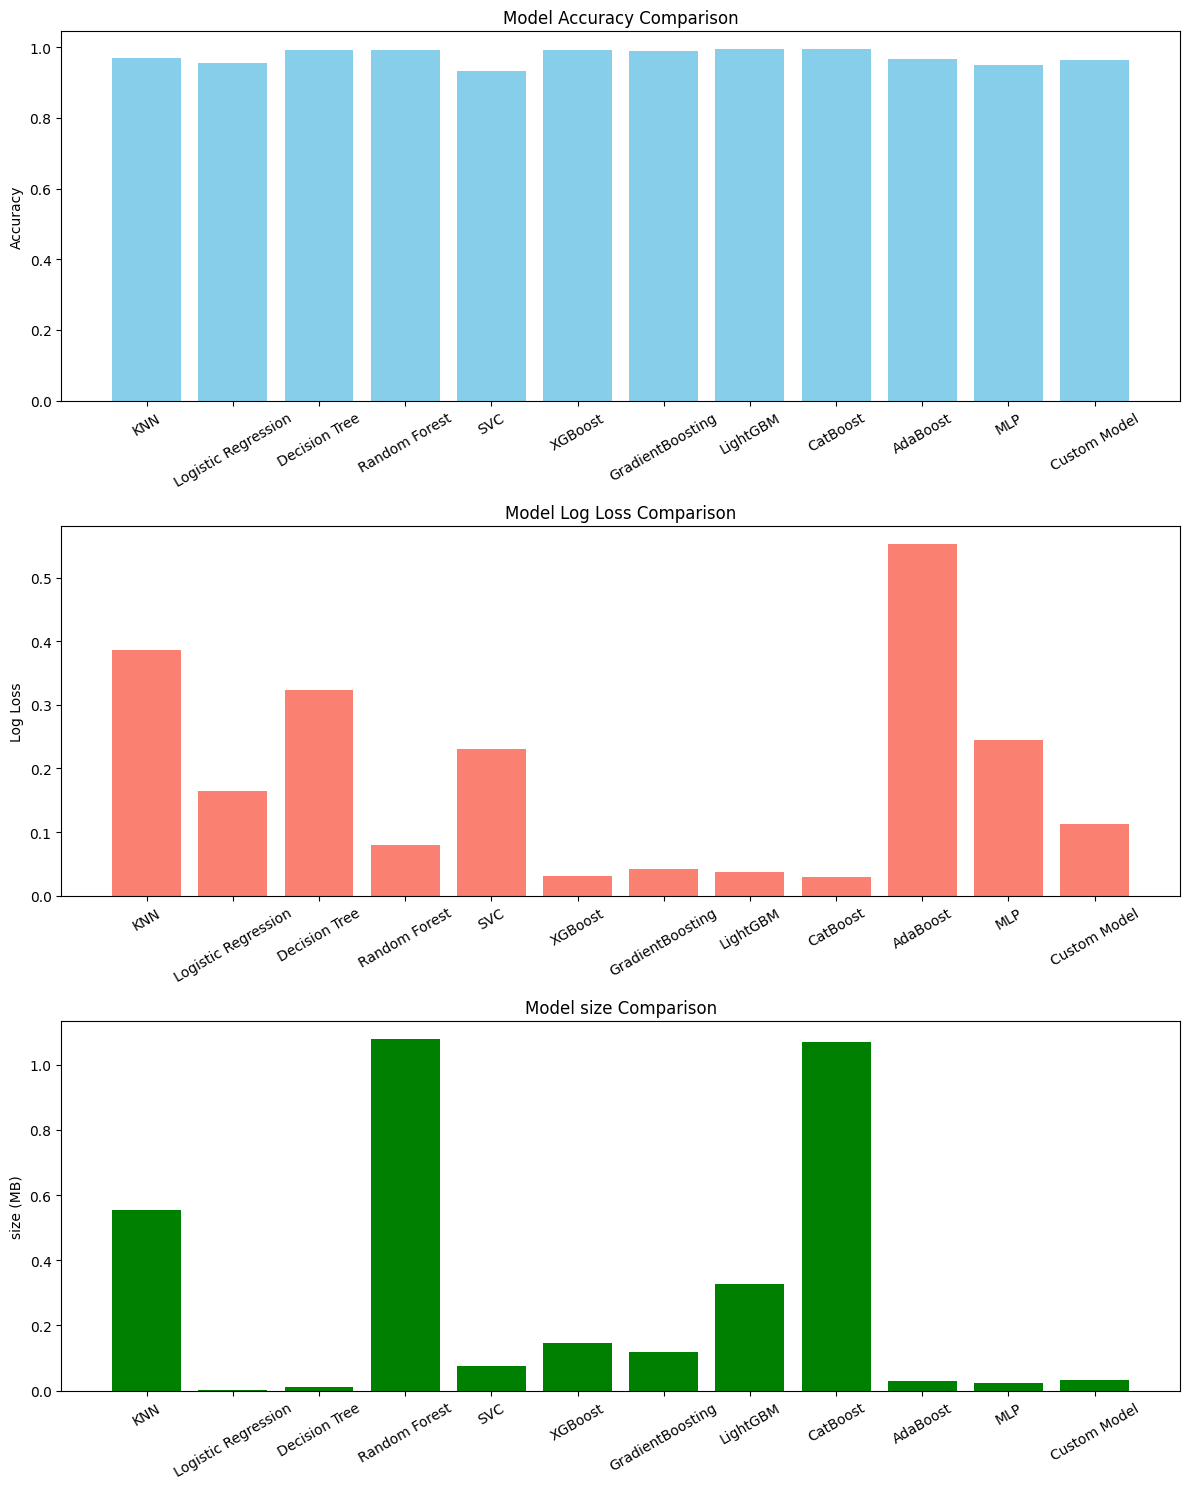

In [71]:
plt.figure(figsize=(12,15))

# Accuracy
plt.subplot(3,1,1)
plt.bar(accuracies.keys(), accuracies.values(), color='skyblue')
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)

# Loss
plt.subplot(3,1,2)
plt.bar(losses.keys(), losses.values(), color='salmon')
plt.title("Model Log Loss Comparison")
plt.ylabel("Log Loss")
plt.xticks(rotation=30)

# Size
plt.subplot(3,1,3)
plt.bar(filesizes.keys(), filesizes.values(), color='green')
plt.title("Model size Comparison")
plt.ylabel("size (MB)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

## Print results

In [72]:
# Print values before plotting
print("=== Model Accuracy Comparison ===")
for model, acc in accuracies.items():
    print(f"{model}: {acc:.4f}")

print("\n=== Model Log Loss Comparison ===")
for model, loss in losses.items():
    print(f"{model}: {loss:.4f}")

print("\n=== Model Size Comparison (MB) ===")
for model, size in filesizes.items():
    print(f"{model}: {size:.2f} MB")

=== Model Accuracy Comparison ===
KNN: 0.9698
Logistic Regression: 0.9551
Decision Tree: 0.9910
Random Forest: 0.9927
SVC: 0.9331
XGBoost: 0.9927
GradientBoosting: 0.9902
LightGBM: 0.9935
CatBoost: 0.9951
AdaBoost: 0.9665
MLP: 0.9494
Custom Model: 0.9649

=== Model Log Loss Comparison ===
KNN: 0.3864
Logistic Regression: 0.1642
Decision Tree: 0.3237
Random Forest: 0.0803
SVC: 0.2301
XGBoost: 0.0313
GradientBoosting: 0.0411
LightGBM: 0.0366
CatBoost: 0.0295
AdaBoost: 0.5530
MLP: 0.2453
Custom Model: 0.1127

=== Model Size Comparison (MB) ===
KNN: 0.56 MB
Logistic Regression: 0.00 MB
Decision Tree: 0.01 MB
Random Forest: 1.08 MB
SVC: 0.08 MB
XGBoost: 0.15 MB
GradientBoosting: 0.12 MB
LightGBM: 0.33 MB
CatBoost: 1.07 MB
AdaBoost: 0.03 MB
MLP: 0.02 MB
Custom Model: 0.03 MB
